In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(29)

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [4]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1, random_state=29).reset_index(drop=True)


In [5]:
df.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid2,186.0,10.0,150.0,350.0,167.0,167.0,166.0
1,rpi-4a,16.2,17.4,1446.0,17.8,435.5,17.1,19.3
2,odroid1,165.0,167.0,167.0,168.0,169.0,166.0,168.0
3,odroid4,169.0,175.0,176.0,174.0,174.0,173.0,173.0
4,rpi-8c,24.9,629.1,16.7,2092.1,16.1,17.3,17.6


In [6]:
len(df)

18000

# Whats the optimal amount of training data?

In [10]:
stats_df = pd.DataFrame(columns=['data_amount', 'accuracy', 'balanced_accuracy', 'mcc'])
best_model = {}
best_features = {}

for i in range(1000, 13000, 1000):
    train_data = df.head(i)
    test_data = df.tail(5000)

    predictor = TabularPredictor(label='label', eval_metric='mcc').fit(train_data, num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)
    y_pred = predictor.predict(test_data)
    y_pred_proba = predictor.predict_proba(test_data)
    results = predictor.evaluate(test_data)

    new_row = {'data_amount': i, 'accuracy': results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    stats_df.loc[len(stats_df)] = new_row

    model_leaderboard = predictor.leaderboard(test_data)
    # Which models came in the top three on the leaderboard most often?
    if model_leaderboard.loc[0]['model'] not in best_model:
        best_model[model_leaderboard.loc[0]['model']] = 1
    else:
        best_model[model_leaderboard.loc[0]['model']] += 1

    if model_leaderboard.loc[1]['model'] not in best_model:
        best_model[model_leaderboard.loc[1]['model']] = 1
    else:
        best_model[model_leaderboard.loc[1]['model']] += 1

    if model_leaderboard.loc[2]['model'] not in best_model:
        best_model[model_leaderboard.loc[2]['model']] = 1
    else:
        best_model[model_leaderboard.loc[2]['model']] += 1


    feature_importance = predictor.feature_importance(test_data)
    # Which features has the highest importance most often?
    if feature_importance.index[0] not in best_features:
        best_features[feature_importance.index[0]] = 1
    else:
        best_features[feature_importance.index[0]] += 1

    if feature_importance.index[1] not in best_features:
        best_features[feature_importance.index[1]] = 1
    else:
        best_features[feature_importance.index[1]] += 1

    if feature_importance.index[2] not in best_features:
        best_features[feature_importance.index[2]] = 1
    else:
        best_features[feature_importance.index[2]] += 1

No path specified. Models will be saved in: "AutogluonModels\ag-20250402_235524"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       50.10 GB / 63.72 GB (78.6%)
Disk Space Avail:   903.81 GB / 1906.98 GB (47.4%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - IoT Classification\AutogluonModels\ag-20250402_235524"
Train Data Rows:    1000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	9 unique label values:  ['odroid2', 'rpi-4a', 'odroid1', 'odroid4', 'rpi-8c', 'odroid3', 'rpi-8a', 'rpi-8d', 'rpi-8b']
	If 'multiclass' is not the correct problem_type, please manually spe

[1000]	valid_set's multi_logloss: 0.472193	valid_set's mcc: 0.840542


	0.8428	 = Validation score   (mcc)
	37.2s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8585	 = Validation score   (mcc)
	11.99s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8475	 = Validation score   (mcc)
	0.53s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8497	 = Validation score   (mcc)
	0.51s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.8319	 = Validation score   (mcc)
	0.49s	 = Training   

[1000]	valid_set's multi_logloss: 0.438439	valid_set's mcc: 0.853948


	0.8597	 = Validation score   (mcc)
	119.28s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8801	 = Validation score   (mcc)
	29.47s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8558	 = Validation score   (mcc)
	0.61s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.852	 = Validation score   (mcc)
	0.59s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.8465	 = Validation score   (mcc)
	0.59s	 = Training  

...

	0.8845	 = Validation score   (mcc)
	43.58s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9021	 = Validation score   (mcc)
	31.46s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8828	 = Validation score   (mcc)
	0.53s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8909	 = Validation score   (mcc)
	0.52s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.8991	 = Validation score   (mcc)
	0.5s	 = Training   

[1000]	valid_set's multi_logloss: 0.39118	valid_set's mcc: 0.863015


	0.8653	 = Validation score   (mcc)
	40.66s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8674	 = Validation score   (mcc)
	23.41s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8552	 = Validation score   (mcc)
	0.59s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8564	 = Validation score   (mcc)
	0.58s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.852	 = Validation score   (mcc)
	0.53s	 = Training   

[1000]	valid_set's multi_logloss: 0.356044	valid_set's mcc: 0.877405


	0.8825	 = Validation score   (mcc)
	53.84s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8866	 = Validation score   (mcc)
	25.84s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8753	 = Validation score   (mcc)
	0.6s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8703	 = Validation score   (mcc)
	0.61s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.8705	 = Validation score   (mcc)
	0.56s	 = Training   

In [11]:
stats_df

,data_amount,accuracy,balanced_accuracy,mcc
0,1000,0.8122,0.812132,0.788946
1,2000,0.7994,0.800012,0.775131
2,3000,0.8588,0.858548,0.841336
3,4000,0.8660,0.865632,0.849574
4,5000,0.8718,0.871666,0.855948
5,6000,0.8794,0.879383,0.864439
6,7000,0.8776,0.877348,0.862349
7,8000,0.8840,0.883861,0.869586
8,9000,0.8846,0.884488,0.870245
9,10000,0.8876,0.887664,0.873641


<Axes: xlabel='data_amount', ylabel='value'>

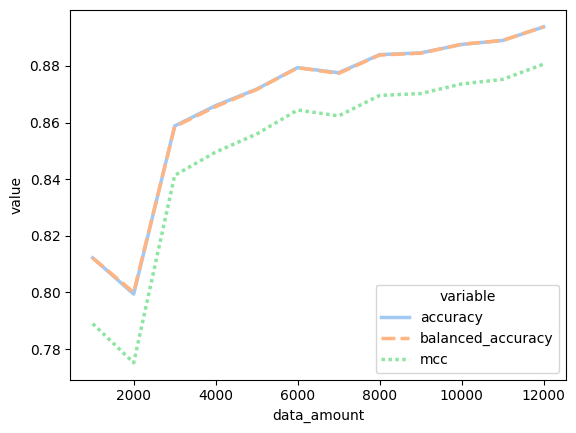

In [12]:
sns.lineplot(data=pd.melt(stats_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [13]:
best_model

{'RandomForestEntr': 8,
 'RandomForestGini': 7,
 'LightGBM': 9,
 'ExtraTreesGini': 1,
 'ExtraTreesEntr': 1,
 'LightGBMLarge': 8,
 'XGBoost': 2}

([<matplotlib.patches.Wedge at 0x1ee094a2ad0>,
 [Text(0.8426488596463491, 0.7070664037675015, 'RandomForestEntr'),
  Text(-0.4648801634046089, 0.9969385305388213, 'RandomForestGini'),
  Text(-1.0625183310459778, -0.28470124023486504, 'LightGBM'),
  Text(-0.4648799890943261, -0.9969386118210386, 'ExtraTreesGini'),
  Text(-0.28470037470372794, -1.0625185629642229, 'ExtraTreesEntr'),
  Text(0.5500003659264656, -0.9526277328950455, 'LightGBMLarge'),
  Text(1.0832885683736377, -0.1910127682407498, 'XGBoost')],
 [Text(0.45962665071619035, 0.38567258387318265, '22%'),
  Text(-0.25357099822069573, 0.5437846530211752, '19%'),
  Text(-0.579555453297806, -0.15529158558265366, '25%'),
  Text(-0.2535709031423597, -0.54378469735693, '3%'),
  Text(-0.15529111347476068, -0.5795555797986669, '3%'),
  Text(0.3000001995962539, -0.5196151270336611, '22%'),
  Text(0.5908846736583478, -0.1041887826767726, '6%')])

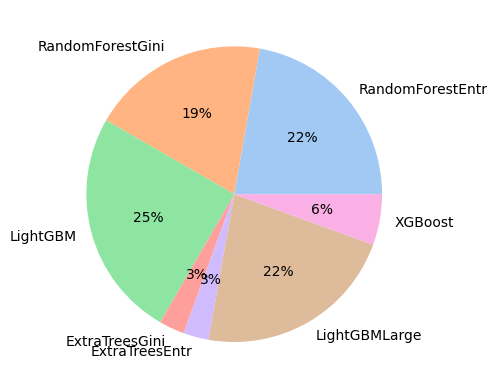

In [14]:
colors = sns.color_palette('pastel')[0:20]
plt.pie(list(best_model.values()), labels=list(best_model), colors = colors, autopct='%.0f%%')

In [15]:
best_features

{'Feature 1': 11,
 'Feature 2': 12,
 'Feature 3': 7,
 'Feature 6': 3,
 'Feature 0': 3}

([<matplotlib.patches.Wedge at 0x1ee0d411e90>,
 [Text(0.6309340917215729, 0.9010672405006599, 'Feature 1'),
  Text(-1.0832885061337203, 0.19101312122095906, 'Feature 2'),
  Text(-0.09587076231926031, -1.0958142164310172, 'Feature 3'),
  Text(0.7778177173879477, -0.7778172012223713, 'Feature 6'),
  Text(1.0625184735920314, -0.28470070824579974, 'Feature 0')],
 [Text(0.34414586821176696, 0.491491222091269, '31%'),
  Text(-0.5908846397093019, 0.10418897521143221, '33%'),
  Text(-0.05229314308323289, -0.5977168453260092, '19%'),
  Text(0.4242642094843351, -0.42426392793947526, '8%'),
  Text(0.5795555310501989, -0.15529129540679984, '8%')])

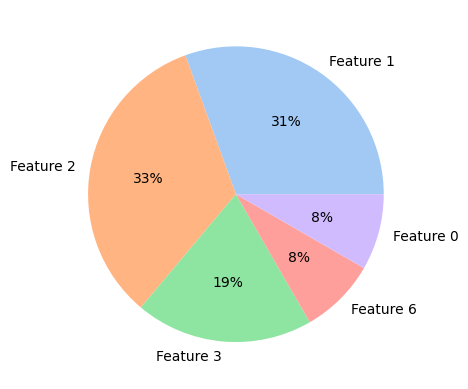

In [16]:
plt.pie(list(best_features.values()), labels=list(best_features), colors = colors, autopct='%.0f%%')

In [17]:
feature_importance

,importance,stddev,p_value,n,p99_high,p99_low
Feature 2,0.170029,0.002115,2.872201e-09,5,0.174383,0.165674
Feature 1,0.108919,0.004024,2.232512e-07,5,0.117205,0.100633
Feature 3,0.097311,0.003798,2.778578e-07,5,0.105131,0.089491
Feature 6,0.079851,0.002453,1.066611e-07,5,0.084901,0.074801
Feature 0,0.076062,0.001478,1.708524e-08,5,0.079104,0.073019
Feature 4,0.072772,0.003028,3.588153e-07,5,0.079006,0.066537
Feature 5,0.058093,0.001252,2.590175e-08,5,0.060672,0.055515


In [18]:
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMLarge,0.899719,mcc,0.018461,80.651519,0.018461,80.651519,1,True,12
1,LightGBM,0.894125,mcc,0.013508,23.556690,0.013508,23.556690,1,True,5
2,RandomForestEntr,0.887598,mcc,0.044659,0.613273,0.044659,0.613273,1,True,7
3,XGBoost,0.882920,mcc,0.025339,6.440723,0.025339,6.440723,1,True,10
4,ExtraTreesEntr,0.880213,mcc,0.044474,0.533383,0.044474,0.533383,1,True,9
5,ExtraTreesGini,0.879262,mcc,0.044222,0.528817,0.044222,0.528817,1,True,8
6,RandomForestGini,0.876325,mcc,0.043797,0.589705,0.043797,0.589705,1,True,6
7,LightGBMXT,0.871747,mcc,0.026202,27.319996,0.026202,27.319996,1,True,4
8,KNeighborsDist,0.861389,mcc,0.022150,0.007760,0.022150,0.007760,1,True,2
9,NeuralNetTorch,0.858866,mcc,0.000000,98.544129,0.000000,98.544129,1,True,11


In [19]:
# will return the path to the cloned predictor, identical to save_path_clone_opt
path_clone_opt = predictor.clone_for_deployment(path='classification')

Cloned TabularPredictor located in 'c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - IoT Classification\AutogluonModels\ag-20250403_005118' to 'classification'.
	To load the cloned predictor: predictor_clone = TabularPredictor.load(path="classification")
Clone: Keeping minimum set of models required to predict with best model 'LightGBMLarge'...
Deleting model KNeighborsUnif. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - IoT Classification\classification\models\KNeighborsUnif will be removed.
Deleting model KNeighborsDist. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - IoT Classification\classification\models\KNeighborsDist will be removed.
Deleting model NeuralNetFastAI. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - IoT Classification\classification\models\NeuralNetFastAI will be removed.
Deleting model LightGBMXT. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - IoT Classificatio

In [20]:
predictor_clone_opt = TabularPredictor.load(path='classification')

In [21]:
predictor_clone_opt.leaderboard(test_data)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMLarge,0.880644,0.899719,mcc,0.076258,0.018461,80.651519,0.076258,0.018461,80.651519,1,True,1


In [22]:
# with ensemble size was 450mb, accuracy was only 1.2% better...
size_original = predictor.disk_usage()
size_opt = predictor_clone_opt.disk_usage()
print(f'Size Original:  {size_original} bytes')
print(f'Size Optimized: {size_opt} bytes')
print(f'Optimized predictor achieved a {round((1 - (size_opt/size_original)) * 100, 1)}% reduction in disk usage.')

Size Original:  625147252 bytes
Size Optimized: 26605201 bytes
Optimized predictor achieved a 95.7% reduction in disk usage.
